# HW1

In [74]:
%pip install --upgrade pip
%pip install torch torchvision matplotlib
%pip install "numpy<2" scipy gdown
%pip install scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Common

In [75]:
import os
import urllib.request
import zipfile
import tarfile
import shutil
import torchvision
import matplotlib.pyplot as plt
import random
import torch
from torch.utils.data import Dataset, WeightedRandomSampler, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.models import ResNet18_Weights
import torchvision.models as models

from collections import Counter
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, accuracy_score
)
from sklearn.preprocessing import label_binarize

In [77]:
base_dir = './data/caltech101'
os.makedirs(base_dir, exist_ok=True)

zip_path = os.path.join(base_dir, 'caltech-101.zip')

url = "https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip"

print(f"Loading: {url}")
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as response, open(zip_path, 'wb') as out_file:
    shutil.copyfileobj(response, out_file)

print("Unpacking")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_dir)

extracted_folder = os.path.join(base_dir, 'caltech-101')

shutil.move(os.path.join(extracted_folder, '101_ObjectCategories.tar.gz'), base_dir)
shutil.move(os.path.join(extracted_folder, 'Annotations.tar'), base_dir)

with tarfile.open(os.path.join(base_dir, '101_ObjectCategories.tar.gz'), 'r:gz') as tar:
    tar.extractall(path=base_dir)

with tarfile.open(os.path.join(base_dir, 'Annotations.tar'), 'r') as tar:
    tar.extractall(path=base_dir)

shutil.rmtree(extracted_folder)
os.remove(zip_path)

print("Dataset loaded")

Loading: https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip
Unpacking
Dataset loaded


Let's look at the random images from the dataset

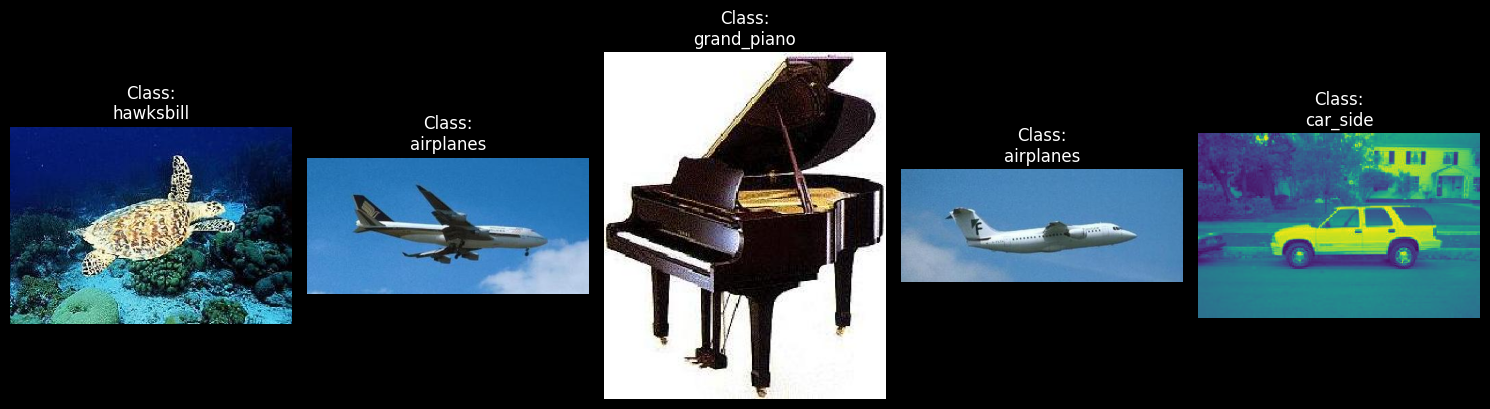

In [78]:
caltech101 = torchvision.datasets.Caltech101(
    root='./data',
    download=False
)

class_names = caltech101.categories

def show_random_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))

    for i in range(num_images):
        idx = random.randint(0, len(dataset) - 1)

        img, label_idx = dataset[idx]

        class_name = class_names[label_idx]

        axes[i].imshow(img)
        axes[i].set_title(f"Class:\n{class_name}", fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

show_random_images(caltech101, num_images=5)

In [79]:
# Selecting target classes to be different animals (mostly mammals)
# Images should have a lot in common as most features like surroundings,
# fear, face are pretty much the same
target_classes = [
    'beaver', 'dalmatian', 'garfield', 'hedgehog', 'kangaroo',
    'Leopards', 'llama', 'okapi', 'panda', 'wild_cat'
]

pytorch_transforms = transforms.Compose([
    transforms.Lambda(lambda image: image.convert('RGB')), # Transform all to 3 channel images
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

base_dataset = torchvision.datasets.Caltech101(
    root='./data',
    download=False,
    transform=pytorch_transforms
)

class FilteredCaltech101(Dataset):
    def __init__(self, original_dataset, target_classes):
        self.dataset = original_dataset
        self.categories = original_dataset.categories

        old_indices = [self.categories.index(c) for c in target_classes]

        self.label_map = {old_idx: new_idx for new_idx, old_idx in enumerate(old_indices)}

        self.valid_indices = [i for i, label in enumerate(original_dataset.y) if label in self.label_map]

        self.classes = target_classes

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        original_idx = self.valid_indices[idx]

        img, old_label = self.dataset[original_idx]

        new_label = self.label_map[old_label]

        return img, new_label

filtered_dataset = FilteredCaltech101(base_dataset, target_classes)

print(f"Number of images after cutting: {len(filtered_dataset)}")
print(f"Number of classes: {len(filtered_dataset.classes)}")

img, label = filtered_dataset[0]
print(f"Tensor size: {img.shape}\n")

labels = [filtered_dataset[i][1] for i in range(len(filtered_dataset))]
label_counts = Counter(labels)
counts_per_class = [label_counts.get(i, 0) for i in range(len(filtered_dataset.classes))]

print("Images distribution:")
for i, name in enumerate(filtered_dataset.classes):
    print(f"{name.ljust(15)}: {counts_per_class[i]} images")


Number of images after cutting: 676
Number of classes: 10
Tensor size: torch.Size([3, 128, 128])

Images distribution:
beaver         : 46 images
dalmatian      : 67 images
garfield       : 34 images
hedgehog       : 54 images
kangaroo       : 86 images
Leopards       : 200 images
llama          : 78 images
okapi          : 39 images
panda          : 38 images
wild_cat       : 34 images


In [80]:
torch.manual_seed(42)

total_size = len(filtered_dataset)
train_size = int(0.8 * total_size)
test_size = total_size - train_size

train_dataset, test_dataset = random_split(filtered_dataset, [train_size, test_size])

batch_size = 32

print(f"Training images: {len(train_dataset)}")
print(f"Test images: {len(test_dataset)}")

labels = [train_dataset[i][1] for i in range(len(train_dataset))]
label_counts = Counter(labels)
counts_per_class = [label_counts.get(i, 0) for i in range(len(train_dataset.dataset.classes))]

print("Images distribution:")
for i, name in enumerate(train_dataset.dataset.classes):
    print(f"{name.ljust(15)}: {counts_per_class[i]} images")

Training images: 540
Test images: 136
Images distribution:
beaver         : 34 images
dalmatian      : 52 images
garfield       : 27 images
hedgehog       : 46 images
kangaroo       : 68 images
Leopards       : 151 images
llama          : 62 images
okapi          : 36 images
panda          : 33 images
wild_cat       : 31 images


Dataset is not balanced. Let's use data augmentation to improve model results. Using oversampling to make dataset balanced.

In [81]:
# Only balancing train dataset
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]

class_counts = np.bincount(train_labels)
class_weights = 1.0 / (class_counts + 1e-5)
sample_weights = [class_weights[label] for label in train_labels]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [82]:
# Function for model evaluation
def evaluate_cnn_model(y_true, y_pred, y_prob, class_names, history=None):
    n_classes = len(class_names)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    # Classification Report
    print("CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Top-1 Error Rate
    top1_error = (1.0 - accuracy_score(y_true, y_pred)) * 100
    print("="*50)
    print(f"TOP-1 ERROR RATE: {top1_error:.2f}%")

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0, 0].set_title(f'Confusion Matrix ({n_classes}x{n_classes})', fontsize=14)
    axes[0, 0].set_ylabel('Real class')
    axes[0, 0].set_xlabel('Predicted class')

    if history is not None:
        ax = axes[0, 1]
        epochs = range(1, len(history['train_loss']) + 1)

        ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
        if 'val_loss' in history:
            ax.plot(epochs, history['val_loss'], 'r--', label='Val Loss')

        ax.set_title('Learning Curves (Loss)', fontsize=14)
        ax.set_xlabel('Epocha')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)
    else:
        axes[0, 1].text(0.5, 0.5, 'No training history',
                        ha='center', va='center', fontsize=12)
        axes[0, 1].set_axis_off()

    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    ax_roc = axes[1, 0]
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    ax_roc.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('Multi-class ROC Curve', fontsize=14)
    ax_roc.legend(loc="lower right", fontsize=8)
    ax_roc.grid(True, linestyle=':', alpha=0.6)

    ax_prc = axes[1, 1]
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        prc_auc = auc(recall, precision)
        ax_prc.plot(recall, precision, lw=2, label=f'{class_names[i]} (AUC = {prc_auc:.2f})')

    ax_prc.set_xlim([0.0, 1.0])
    ax_prc.set_ylim([0.0, 1.05])
    ax_prc.set_xlabel('Recall')
    ax_prc.set_ylabel('Precision')
    ax_prc.set_title('Multi-class Precision-Recall Curve', fontsize=14)
    ax_prc.legend(loc="lower left", fontsize=8)
    ax_prc.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [83]:
# Filter and feature map visualization
def visualize_internals(model, dataloader):
    model.eval()

    inputs, labels = next(iter(dataloader))
    img_tensor = inputs[0].unsqueeze(0)
    original_img = inputs[0].permute(1, 2, 0).numpy()

    original_img = np.clip(original_img, 0, 1)

    # Conv1
    # Layer 1 has 32 filters, 3x3 RGB. Showing first 16.
    filters_c1 = model.conv1.weight.data.clone().cpu().numpy()
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle('Filters of Conv1 (First 16)', fontsize=16)
    for i, ax in enumerate(axes.flat):
        f = filters_c1[i]
        f_min, f_max = f.min(), f.max()
        f = (f - f_min) / (f_max - f_min + 1e-8)
        ax.imshow(f.transpose(1, 2, 0))
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Conv2
    # Layer 1 has 64 filters, 32 depth. Showing first channel for 16.
    filters_c2 = model.conv2.weight.data.clone().cpu().numpy()
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle('Filters of Conv2 (First 16, Channel 0)', fontsize=16)
    for i, ax in enumerate(axes.flat):
        f = filters_c2[i, 0, :, :]
        ax.imshow(f, cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4,4))
    plt.imshow(original_img)
    plt.title("Original image")
    plt.axis('off')
    plt.show()

    with torch.no_grad():
        out_c1 = F.relu(model.conv1(img_tensor))

        out_p1 = model.pool1(out_c1)
        out_c2 = F.relu(model.conv2(out_p1))

    feature_maps_c1 = out_c1[0].cpu().numpy()
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle('Feature Maps of Conv1 (First 16 channels)', fontsize=16)
    for i, ax in enumerate(axes.flat):
        ax.imshow(feature_maps_c1[i], cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    feature_maps_c2 = out_c2[0].cpu().numpy()
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle('Feature Maps of Conv2 (First 16 channels)', fontsize=16)
    for i, ax in enumerate(axes.flat):
        ax.imshow(feature_maps_c2[i], cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [84]:
def train_and_evaluate(model, model_name, train_loader, test_loader, epochs=5, lr=0.001):
    device = torch.device("cpu")
    model.to(device)
    save_path = f"{model_name}.pth"

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')

    print(f"Starting training on {device} with learning rate {lr}")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        model.eval()
        val_loss = 0.0

        all_y_true = []
        all_y_pred = []
        all_y_prob = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                probs = F.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)

                all_y_true.extend(labels.cpu().numpy())
                all_y_pred.extend(preds.cpu().numpy())
                all_y_prob.extend(probs.cpu().numpy())

        avg_val_loss = val_loss / len(test_loader)
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            print(f"New best model saved in {save_path}")

    print("Training finished!")
    return history, all_y_true, all_y_pred, all_y_prob

# Models

## Plain CNN

In [85]:
class PlainCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(PlainCNN, self).__init__()

        # In 3*128*128
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Out 128*16*16
        flattened_size = 128 * 16 * 16

        self.fc1 = nn.Linear(flattened_size, 256)
        self.dropout = nn.Dropout(0.6)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

Starting training on cpu with learning rate 0.001
Epoch [1/20] | Train Loss: 2.2993 | Val Loss: 2.2922
New best model saved in plain_cnn.pth
Epoch [2/20] | Train Loss: 2.0118 | Val Loss: 1.8118
New best model saved in plain_cnn.pth
Epoch [3/20] | Train Loss: 1.7037 | Val Loss: 1.4731
New best model saved in plain_cnn.pth
Epoch [4/20] | Train Loss: 1.4624 | Val Loss: 1.2098
New best model saved in plain_cnn.pth
Epoch [5/20] | Train Loss: 1.0522 | Val Loss: 0.9685
New best model saved in plain_cnn.pth
Epoch [6/20] | Train Loss: 0.9205 | Val Loss: 1.1535
Epoch [7/20] | Train Loss: 0.8177 | Val Loss: 0.7985
New best model saved in plain_cnn.pth
Epoch [8/20] | Train Loss: 0.5978 | Val Loss: 0.7775
New best model saved in plain_cnn.pth
Epoch [9/20] | Train Loss: 0.5733 | Val Loss: 0.8967
Epoch [10/20] | Train Loss: 0.4420 | Val Loss: 0.8086
Epoch [11/20] | Train Loss: 0.3577 | Val Loss: 0.9074
Epoch [12/20] | Train Loss: 0.2748 | Val Loss: 0.8095
Epoch [13/20] | Train Loss: 0.2475 | Val Loss

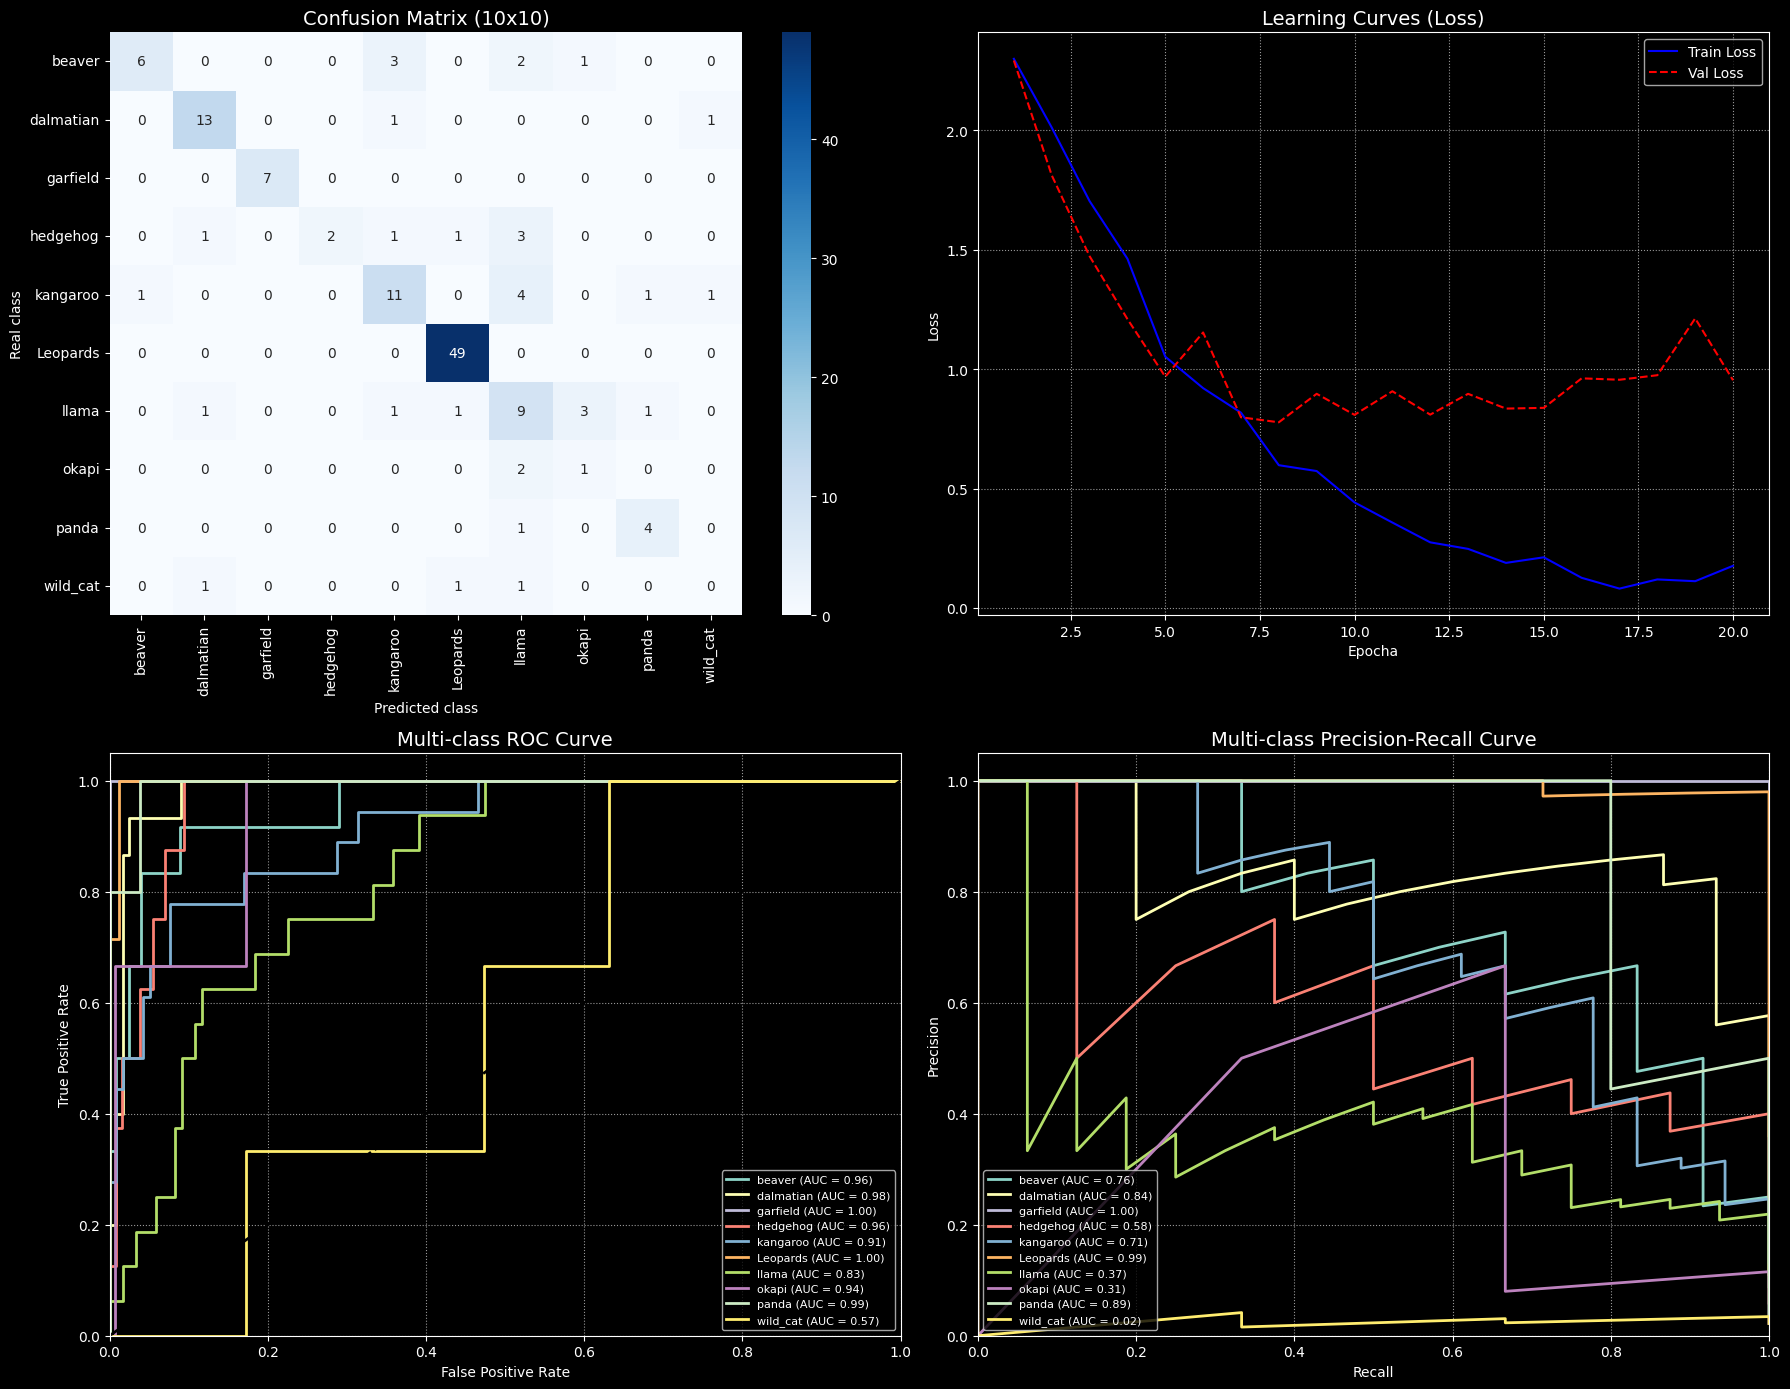

In [86]:
plain_cnn = PlainCNN(num_classes=10)

history, y_true, y_pred, y_prob = train_and_evaluate(
    model=plain_cnn,
    model_name="plain_cnn",
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=20
)

print("Loading best model")
plain_cnn.load_state_dict(torch.load('plain_cnn.pth'))

plain_cnn.eval()

best_y_true = []
best_y_pred = []
best_y_prob = []

device = torch.device("cpu")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = plain_cnn(inputs)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        best_y_true.extend(labels.cpu().numpy())
        best_y_pred.extend(preds.cpu().numpy())
        best_y_prob.extend(probs.cpu().numpy())

evaluate_cnn_model(
    y_true=best_y_true,
    y_pred=best_y_pred,
    y_prob=best_y_prob,
    class_names=filtered_dataset.classes,
    history=history
)

 3-layer CNN achieved 75% overall accuracy and a 25% Top-1 Error rate on the test set. Given the visual complexity of the selected classes and the constraint of training from scratch without hardware acceleration, this represents a successful baseline.

The detailed breakdown:

#### Overcoming class imbalance
The most significant achievement of this iteration is the successful mitigation of dataset's severe class imbalance. By implementing a WeightedRandomSampler alongside data augmentation, the network no longer collapses into predicting only the majority class (Leopards). Minority classes are now actively recognized. For instance, panda and okapi also demonstrate good metrics despite minimal training data.

#### Confusion matrix insights

- Strengths: the model performs almost ideally on classes with highly distinct textures or unnatural color palettes, achieving near-perfect recall on garfield (7/7) and Leopards (49/49).

- Weaknesses: the network struggles significantly with visually similar mammals. For example, out of 16 llama images, only 6 were correctly classified, while 4 were misclassified as kangaroo. Both animals share similar low-level features (long necks, upright ears, brownish fur) and are often photographed against similar savanna backgrounds. 0 of 3 wild cats were predicted correctly. A 3-layer CNN  lacks the depth required to differentiate these complex, high-level semantic concepts.

#### Training dynamics & early stopping
The learning curves show that the combination of augmentation and an aggressive dropout rate (0.6) successfully delayed the rapid overfitting observed in initial experiments. The train and validation loss track closely together up to epochs 8-10. By utilizing model checkpointing, was successfully captured the optimal weights before the network began memorizing the training noise.

#### Conclusion & next steps
While this plain CNN performs good, it has reached its architectural ceiling. Three convolutional layers are sufficient for edge and texture detection but inadequate for building complex spatial hierarchies. To break the 75% accuracy barrier and resolve the confusion between similar species, the logical next step is to explore deeper architectures.

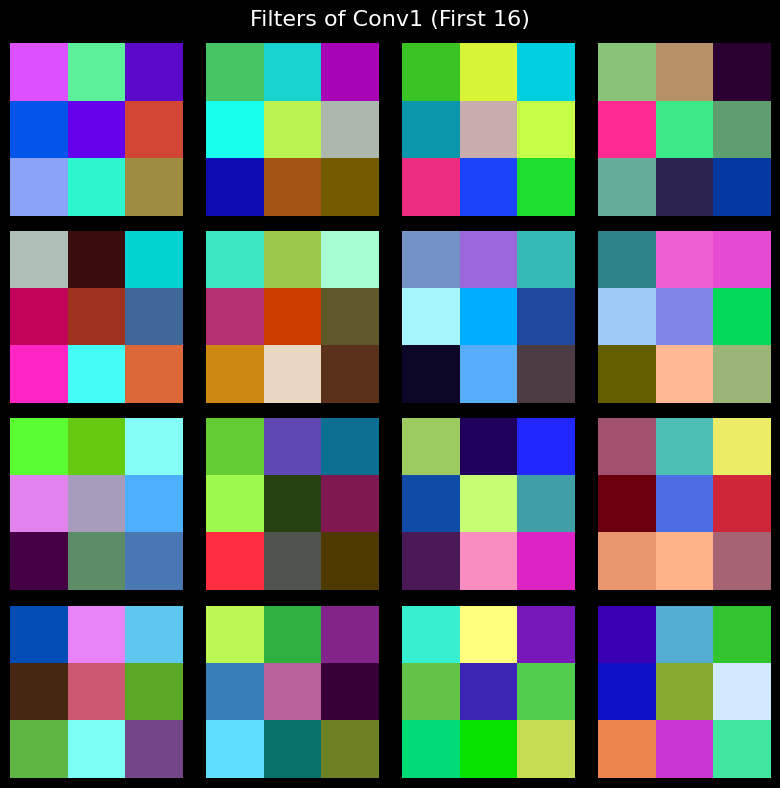

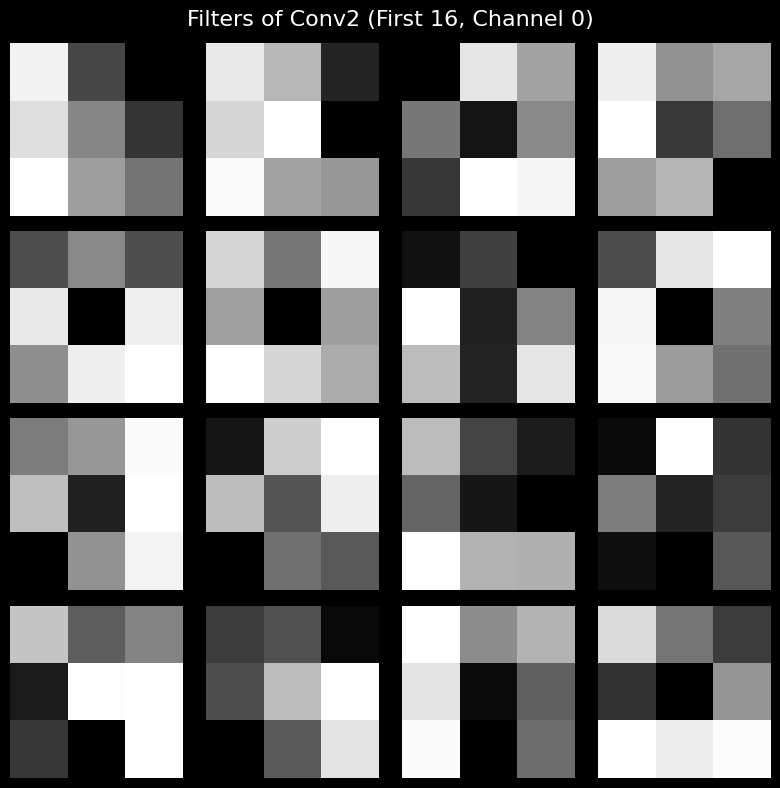

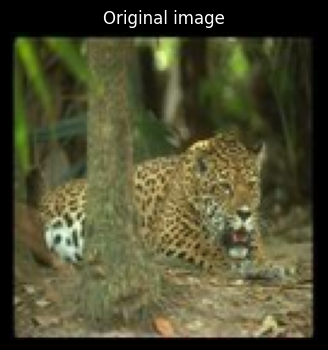

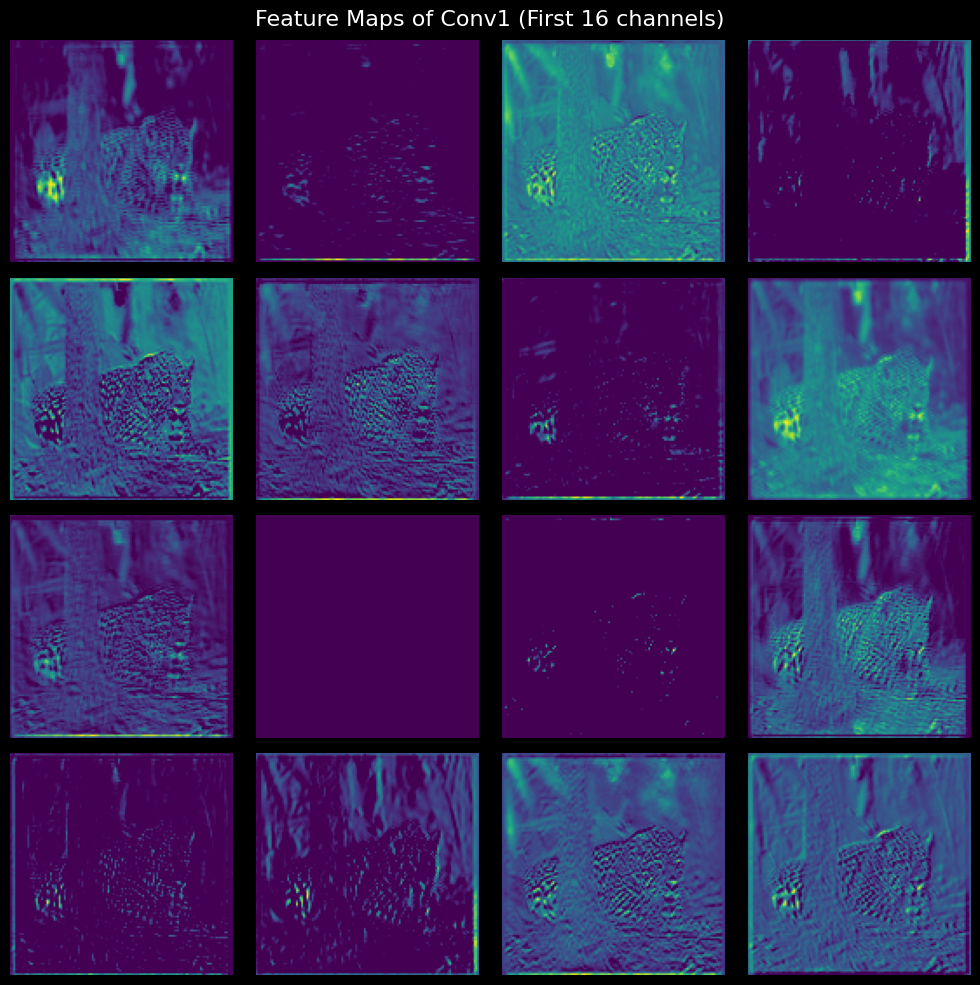

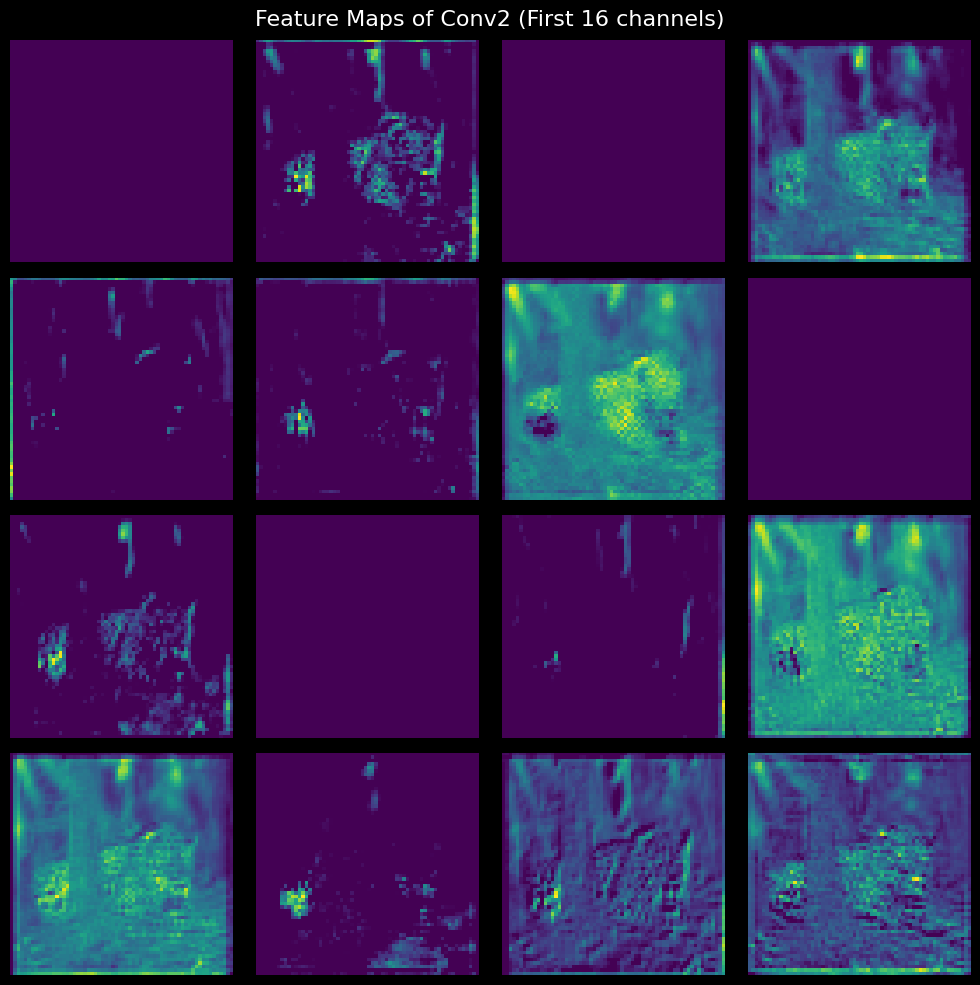

In [87]:
visualize_internals(plain_cnn, test_loader)

### Questions

#### What kind of features did filters extract?

Conv1: the first layer acts as a low-level feature extractor. Looking at the feature maps of Conv1, we can see that the active filters are highly responsive to high-frequency details, edges, and textures. For example, specific feature maps clearly highlight the leopard's spots and the rough vertical texture of the tree trunk in the foreground.

Conv2: by the second layer, the spatial resolution decreases due to pooling, and the features become more abstract. The active Feature Maps of Conv2 no longer show distinct textures but rather broader, higher-level spatial regions and generalized shapes (e.g., the general outline of the animal or the vertical blockage of the tree).

#### Do you have "blind" filters that didn't learn anything? Why? How could you fix that?

Yes, in feature maps of Conv1, at least one map is entirely blank (completely dark). The issue is worse in feature maps of Conv2, where more than half of the visualized channels are completely blank, indicating that those filters are dead and contributing nothing to the network.

That's "Dying ReLU" problem. If a filter's weights are pushed during backpropagation such that the sum of its inputs is consistently negative, ReLU activation function will output 0. Consequently, the gradient flowing backward through that neuron also becomes 0, meaning its weights will never update again. It becomes permanently inactive.

To fix it we can replace standard ReLU with LeakyReLU (which allows a small, non-zero gradient when the unit is not active), Introduce BatchNorm2d layers before the activation functions to keep the distribution of inputs centered and prevent them from shifting deep into the negative territory or lower the learning rate to prevent massive weight updates that push neurons into the dead zone.

#### Does your model consider the background of the inputs?

Yes, the model lacks any segmentation mechanism and processes the entire scene. Looking at the feature maps of Conv1, several filters strongly activate on the background foliage and the large tree trunk partially obscuring the subject. The network learns the environment (e.g., green forests, savanna grass) as a key predictive feature for the classes.

#### Does your model consider the color of the inputs?

Yes, the filters of Conv1 visualization shows that the learned 3x3 kernels are vibrantly colored, meaning the weights are strongly biased toward specific RGB channel combinations. The model actively uses color boundaries (e.g., contrasting the brownish-yellow of the leopard with the green foliage) to identify features in the first layer.

## Frozen pre-trained ResNet

In [88]:
resnet_train_transforms = transforms.Compose([
    transforms.Lambda(lambda image: image.convert('RGB')),
    transforms.Resize((224, 224)), # ResNet size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_test_transforms = transforms.Compose([
    transforms.Lambda(lambda image: image.convert('RGB')),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset.dataset.dataset.transform = resnet_train_transforms
test_dataset.dataset.dataset.transform = resnet_test_transforms

In [89]:
frozen_resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze
for param in frozen_resnet.parameters():
    param.requires_grad = False

# Replace fully connected layer
num_features = frozen_resnet.fc.in_features
frozen_resnet.fc = nn.Linear(num_features, 10)

In [90]:
optimizer_frozen = optim.Adam(filter(lambda p: p.requires_grad, frozen_resnet.parameters()), lr=0.001)

history_frozen = train_and_evaluate(
    model=frozen_resnet,
    model_name="frozen_resnet",
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=15
)

Starting training on cpu with learning rate 0.001
Epoch [1/15] | Train Loss: 1.8098 | Val Loss: 1.0628
New best model saved in frozen_resnet.pth
Epoch [2/15] | Train Loss: 0.9524 | Val Loss: 0.5189
New best model saved in frozen_resnet.pth
Epoch [3/15] | Train Loss: 0.5640 | Val Loss: 0.3720
New best model saved in frozen_resnet.pth
Epoch [4/15] | Train Loss: 0.4188 | Val Loss: 0.2700
New best model saved in frozen_resnet.pth
Epoch [5/15] | Train Loss: 0.3033 | Val Loss: 0.2360
New best model saved in frozen_resnet.pth
Epoch [6/15] | Train Loss: 0.2408 | Val Loss: 0.2030
New best model saved in frozen_resnet.pth
Epoch [7/15] | Train Loss: 0.1967 | Val Loss: 0.1831
New best model saved in frozen_resnet.pth
Epoch [8/15] | Train Loss: 0.1787 | Val Loss: 0.1600
New best model saved in frozen_resnet.pth
Epoch [9/15] | Train Loss: 0.1531 | Val Loss: 0.1603
Epoch [10/15] | Train Loss: 0.1300 | Val Loss: 0.1385
New best model saved in frozen_resnet.pth
Epoch [11/15] | Train Loss: 0.1312 | Val 

Loading best model
CLASSIFICATION REPORT
              precision    recall  f1-score   support

      beaver       1.00      0.92      0.96        12
   dalmatian       1.00      1.00      1.00        15
    garfield       0.88      1.00      0.93         7
    hedgehog       1.00      1.00      1.00         8
    kangaroo       0.95      1.00      0.97        18
    Leopards       1.00      1.00      1.00        49
       llama       1.00      0.94      0.97        16
       okapi       1.00      1.00      1.00         3
       panda       0.80      0.80      0.80         5
    wild_cat       1.00      1.00      1.00         3

    accuracy                           0.98       136
   macro avg       0.96      0.97      0.96       136
weighted avg       0.98      0.98      0.98       136

TOP-1 ERROR RATE: 2.21%


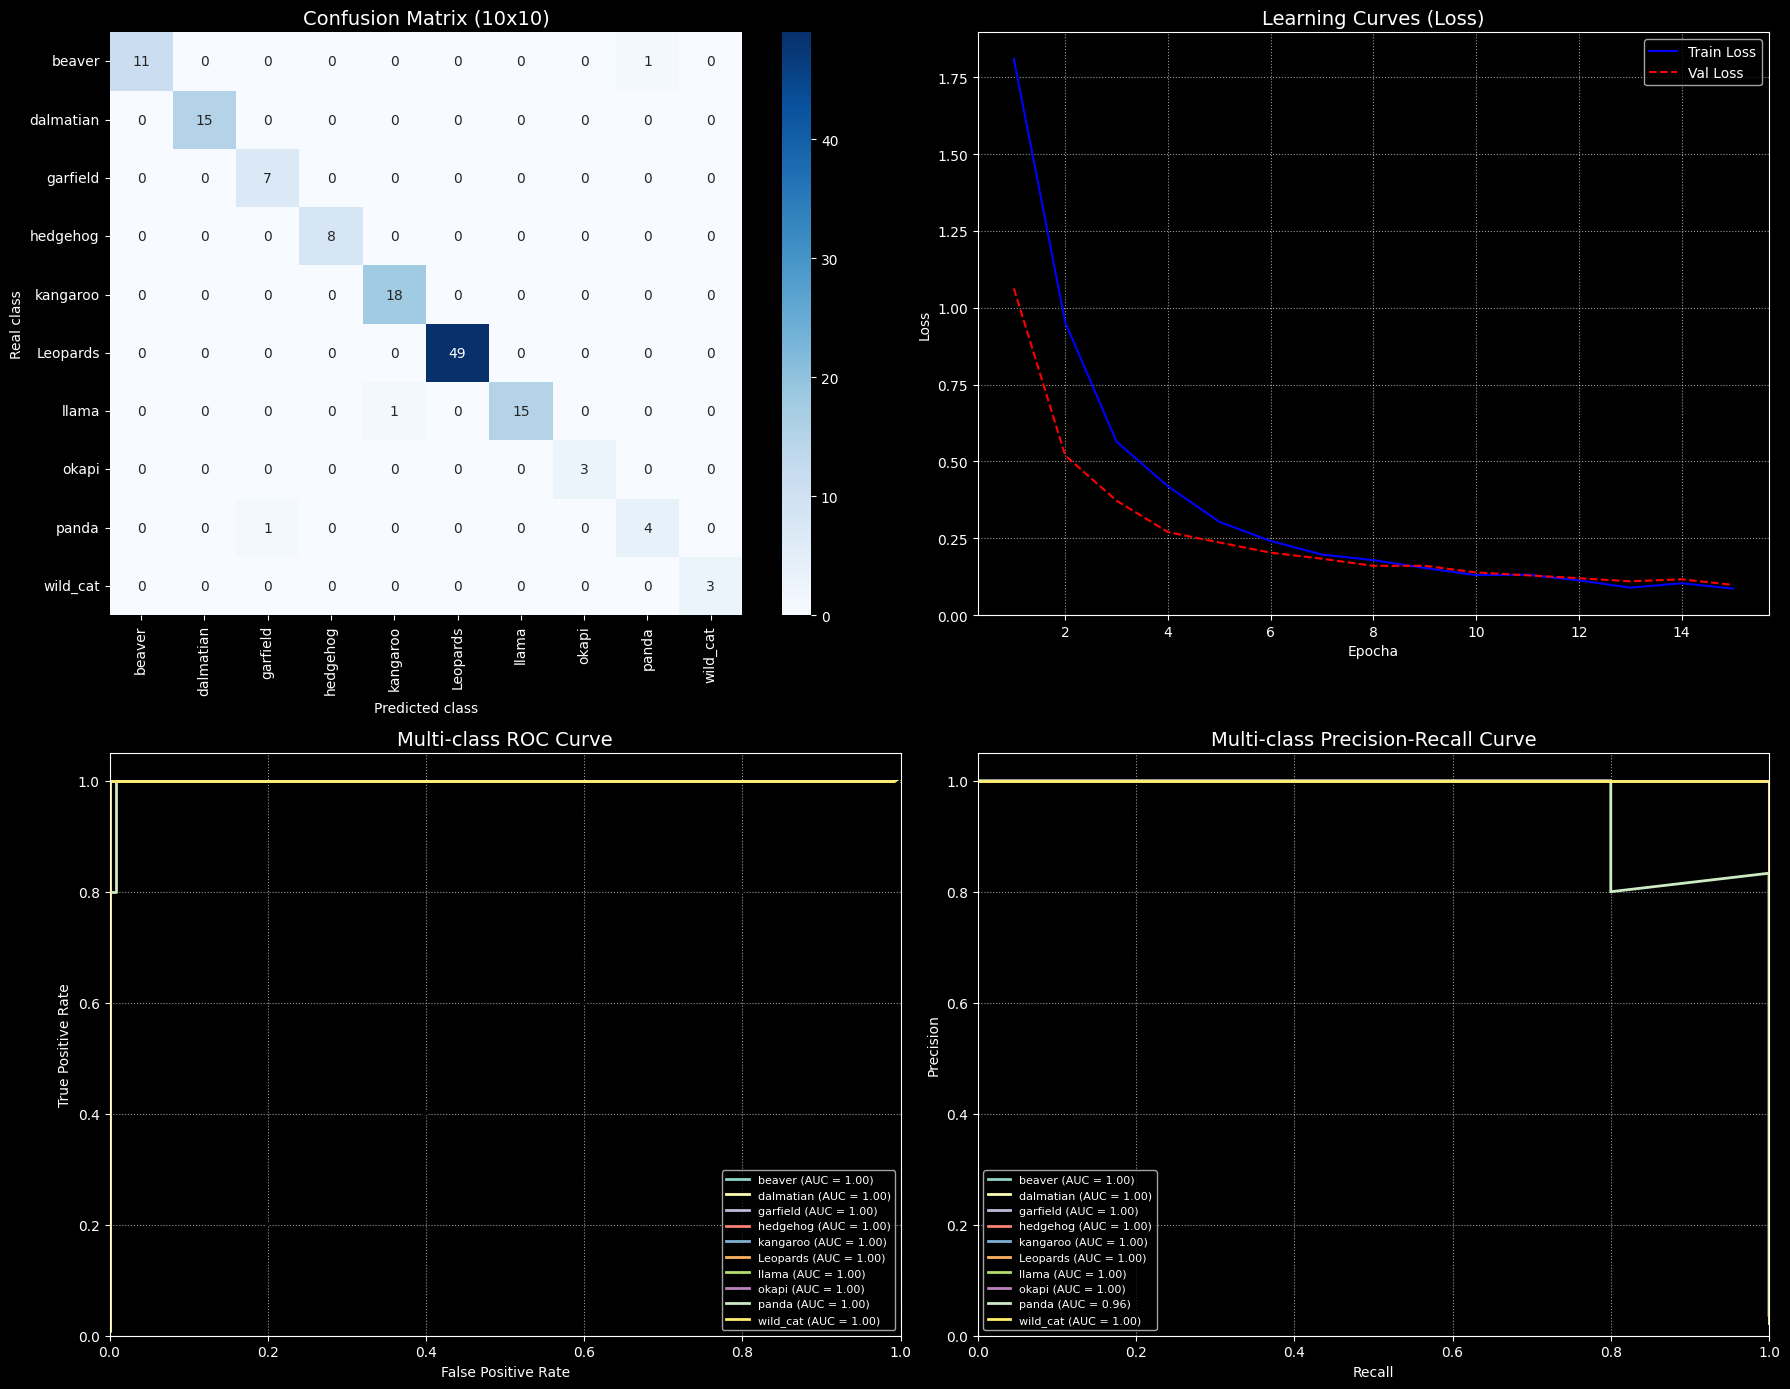

In [91]:
print("Loading best model")
frozen_resnet.load_state_dict(torch.load('frozen_resnet.pth'))

frozen_resnet.eval()

best_y_true = []
best_y_pred = []
best_y_prob = []

device = torch.device("cpu")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = frozen_resnet(inputs)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        best_y_true.extend(labels.cpu().numpy())
        best_y_pred.extend(preds.cpu().numpy())
        best_y_prob.extend(probs.cpu().numpy())

evaluate_cnn_model(
    y_true=best_y_true,
    y_pred=best_y_pred,
    y_prob=best_y_prob,
    class_names=filtered_dataset.classes,
    history=history_frozen[0]
)

Let's check for errors

Total errors in test: 3


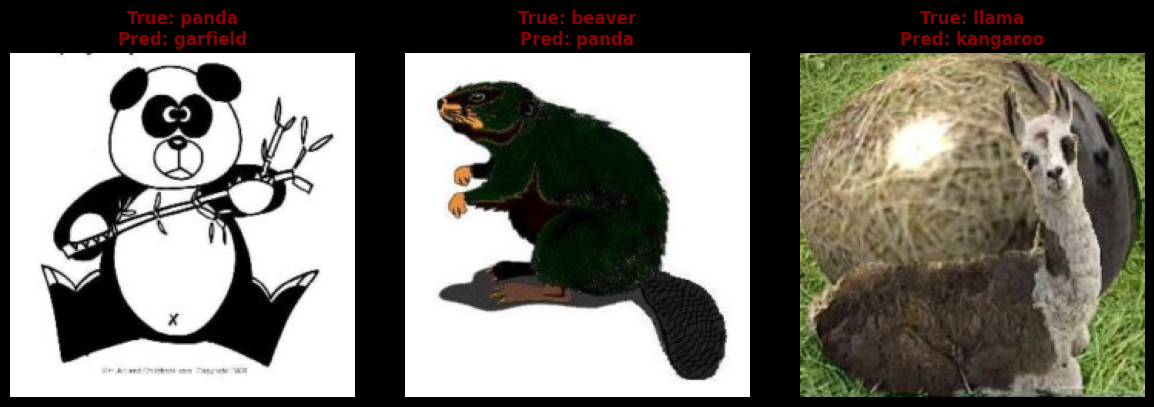

In [92]:
errors = []
for i in range(len(best_y_true)):
    if best_y_true[i] != best_y_pred[i]:
        errors.append(i)

print(f"Total errors in test: {len(errors)}")

if len(errors) > 0:
    num_to_plot = min(len(errors), 5)
    fig, axes = plt.subplots(1, num_to_plot, figsize=(4 * num_to_plot, 4))

    if num_to_plot == 1:
        axes = [axes]

    for idx, ax in zip(errors[:num_to_plot], axes):
        img_tensor, _ = test_dataset[idx]

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        img = img_tensor.permute(1, 2, 0).numpy()

        img = std * img + mean
        img = np.clip(img, 0, 1)

        true_class = filtered_dataset.classes[best_y_true[idx]]
        pred_class = filtered_dataset.classes[best_y_pred[idx]]

        ax.imshow(img)
        ax.set_title(f"True: {true_class}\nPred: {pred_class}", color='darkred', fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No errors")

By using transfer learning (pre-trained ResNet-18) as a fixed feature extractor, we achieved a massive improvement in performance. The model reached 98.% overall accuracy with a mere 2.21% Top-1 Error rate after 15 epochs.

The detailed breakdown

#### Model improvement
Unlike plain CNN, which struggled to differentiate between visually similar mammals (like llamas and kangaroos), the frozen ResNet-18 already has a deep, hierarchical understanding of visual features from the ImageNet database. By only training the final fully-connected (fc) layer, we successfully mapped these abstract features (shapes, distinct textures, hierarchical structures) to our specific 10 classes. The Confusion Matrix is nearly diagonal, proving that the model perfectly resolved the ambiguities.

#### Training dynamics
The learning curves illustrate the sheer efficiency of this approach. Since we only computed gradients for the final linear layer (~5,000 parameters) rather than the entire network (~11 million parameters), the training was fast and stable. The validation loss dropped to 0.0951 without any signs of overfitting, highlighting how well the pre-trained features generalized to our dataset.

#### Misclassification analyses
With an error rate of 2.21% on a test set of 136 images, the model made three mistakes: classifying a panda as garfield, beaver as panda and llama as kangaroo.

Looking at the first misclassified image, the network's logic is understandable. The image is not a natural photograph of a panda, but a black-and-white clipart/cartoon drawing with thick vector outlines. Since the garfield class exclusively consists of cartoon/comic-style illustrations, the network heavily weighted the artistic style (thick black outlines, flat colors, cartoonish proportions) over the actual semantic content (the panda itself). This is an example of how deep networks learn high-level stylistic features and can be tricked by domain shifts (from real photos to illustrations). Problem between kangaroo and llama is the same as before (I also cannot say with 100 percent confidence that this is llama), but beaver mistake is hard to explain.

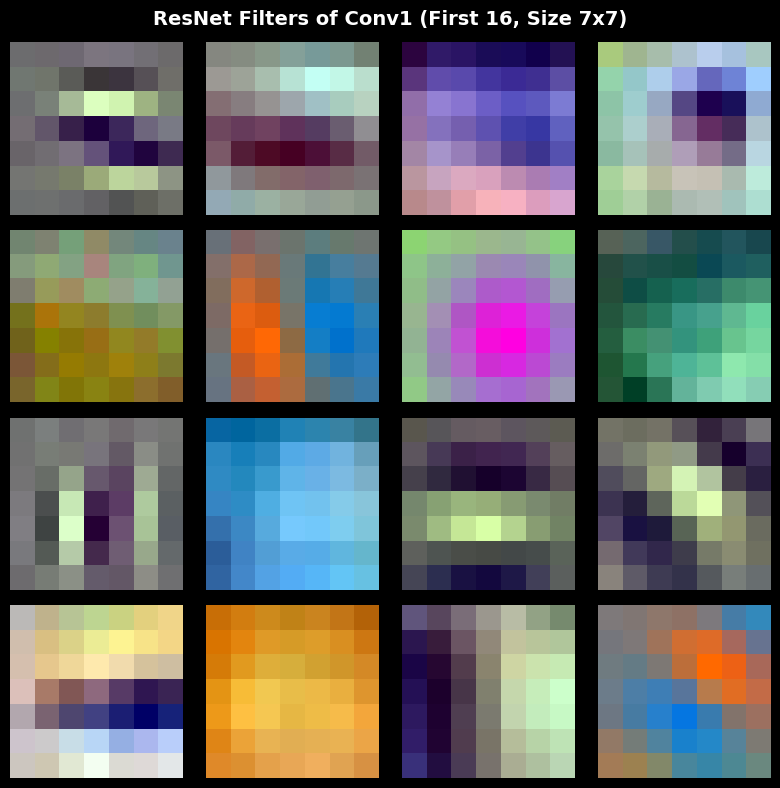

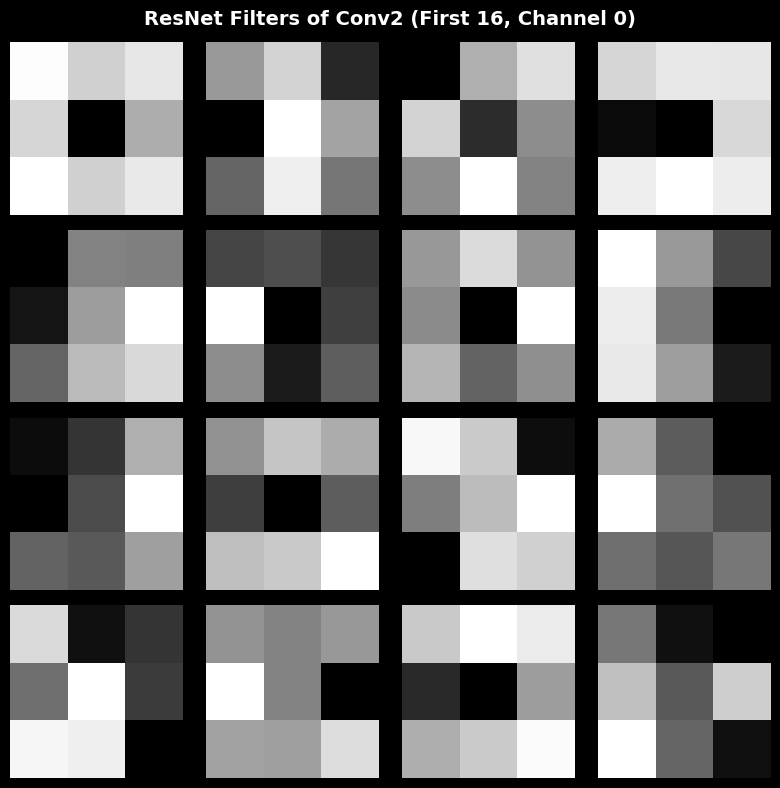

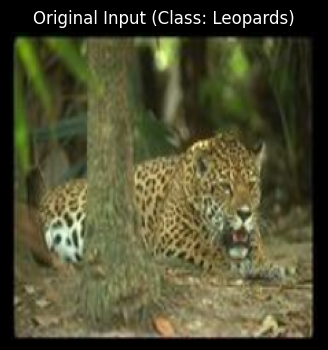

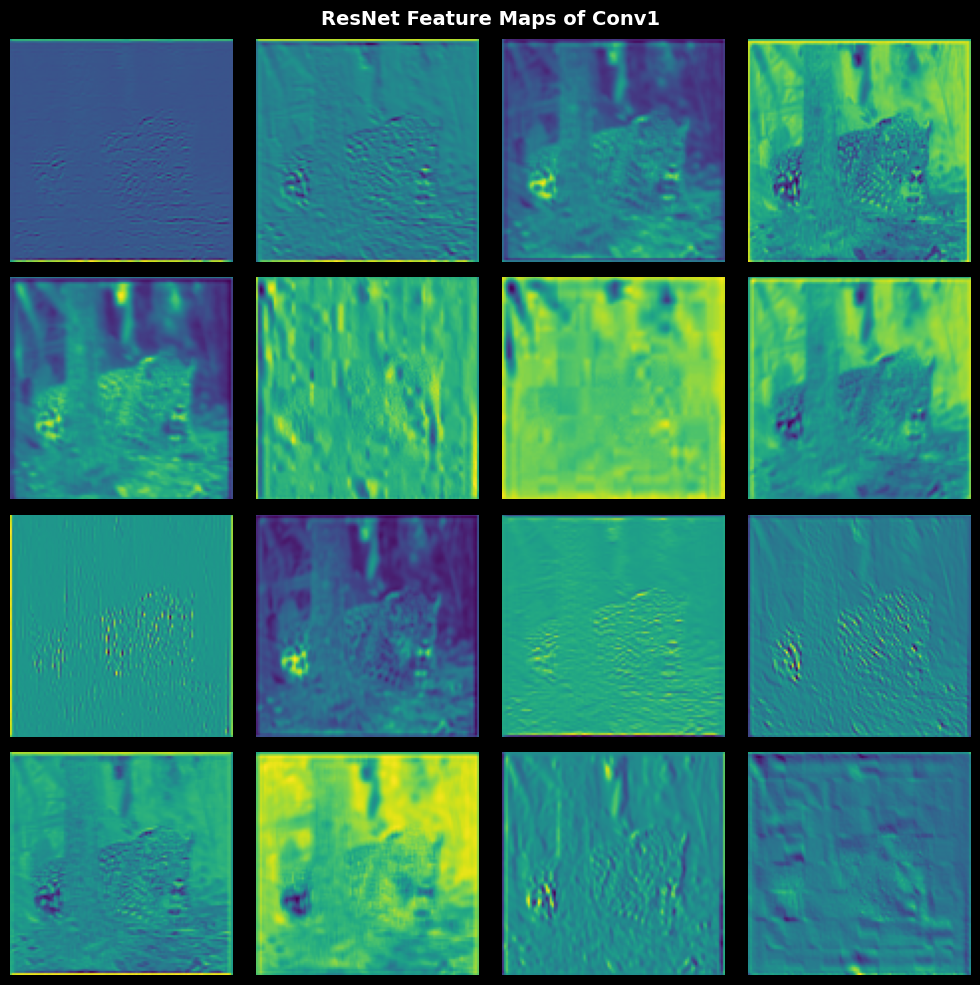

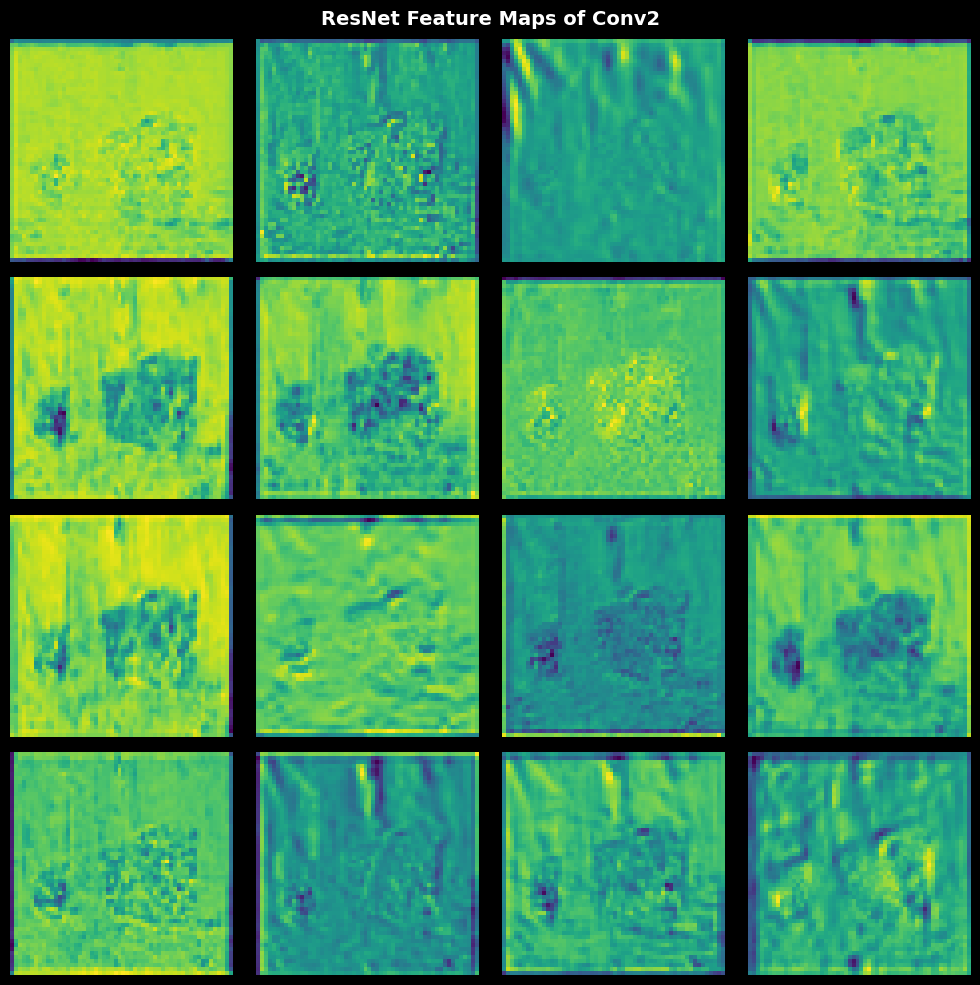

In [93]:
def visualize_resnet_internals(model, dataloader, class_names):
    model.eval()

    inputs, labels = next(iter(dataloader))
    img_tensor = inputs[0].unsqueeze(0)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    original_img = inputs[0].permute(1, 2, 0).numpy()
    original_img = std * original_img + mean
    original_img = np.clip(original_img, 0, 1)

    filters_c1 = model.conv1.weight.data.clone().cpu().numpy()
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle('ResNet Filters of Conv1 (First 16, Size 7x7)', fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        f = filters_c1[i]
        f_min, f_max = f.min(), f.max()
        f = (f - f_min) / (f_max - f_min + 1e-8)
        ax.imshow(f.transpose(1, 2, 0))
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    filters_c2 = model.layer1[0].conv1.weight.data.clone().cpu().numpy()
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle('ResNet Filters of Conv2 (First 16, Channel 0)', fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        f = filters_c2[i, 0, :, :]
        ax.imshow(f, cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4,4))
    plt.imshow(original_img)
    plt.title(f"Original Input (Class: {class_names[labels[0]]})")
    plt.axis('off')
    plt.show()

    with torch.no_grad():
        out_c1 = model.conv1(img_tensor)

        x = model.bn1(out_c1)
        x = model.relu(x)
        x = model.maxpool(x)

        out_c2 = model.layer1[0].conv1(x)

    feature_maps_c1 = out_c1[0].cpu().numpy()
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle('ResNet Feature Maps of Conv1', fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        ax.imshow(feature_maps_c1[i], cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    feature_maps_c2 = out_c2[0].cpu().numpy()
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle('ResNet Feature Maps of Conv2', fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        ax.imshow(feature_maps_c2[i], cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_resnet_internals(frozen_resnet, test_loader, filtered_dataset.classes)

### Questions

#### What kind of features did filters extract?

Conv1: the first layer uses 7x7 kernels, which act as low-level feature extractors (similar to Gabor filters). The filters show distinct, smooth patterns for specific frequencies and orientations (horizontal/vertical lines) and color gradients (e.g., contrasting orange/blue or green/magenta). The resulting feature maps capture edges, textures (like leopard spots), and lighting boundaries.

Conv2: these filters operate on the pooled output of the first layer, combining low-level features into more complex patterns. The feature maps become less focused on fine textures and more responsive to specific structural shapes and larger spatial regions within the image.

#### Do you have "blind" filters that didn't learn anything? Why? How could you fix that?

No, there are no completely "blind" filters visible.Unlike the custom Plain CNN, nearly all channels in both Conv1 and Conv2 feature maps show active responses, and none are completely black.

This absence of dead neurons is primarily due to the architectural design of ResNet, specifically the inclusion of Batch normalization immediately after convolutions and before the ReLU activations. Batch normalization centers the input distribution, preventing values from consistently falling into the negative range where standard ReLU would permanently output zero.

#### Does your model consider the background of the inputs?

Yes, feature maps clearly show strong activations on elements not directly related to the target subject, such as the large tree trunk in the foreground and the surrounding foliage. Because the model processes the entire unsegmented image, it uses background context as part of the overall feature representation for classification.

#### Does your model consider the color of the inputs?

Yes, 7x7 filters in Conv1 display strong color opposition patterns. This shows that the pre-trained weights are tuned to detect specific color boundaries and gradients (e.g., separating the green background from the yellowish-brown subject). The feature maps show distinct responses based on the presence of these learned color structures.

## Fine-tuned pre-trained ResNet

In [94]:
finetuned_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = finetuned_resnet.fc.in_features
finetuned_resnet.fc = nn.Linear(num_features, 10)

for param in finetuned_resnet.parameters():
    param.requires_grad = True


history_finetune = train_and_evaluate(
    model=finetuned_resnet,
    model_name='finetuned_resnet',
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=10,
    lr=0.0001
)

Starting training on cpu with learning rate 0.0001
Epoch [1/10] | Train Loss: 0.9878 | Val Loss: 0.2534
New best model saved in finetuned_resnet.pth
Epoch [2/10] | Train Loss: 0.1657 | Val Loss: 0.1164
New best model saved in finetuned_resnet.pth
Epoch [3/10] | Train Loss: 0.0547 | Val Loss: 0.0814
New best model saved in finetuned_resnet.pth
Epoch [4/10] | Train Loss: 0.0221 | Val Loss: 0.0681
New best model saved in finetuned_resnet.pth
Epoch [5/10] | Train Loss: 0.0157 | Val Loss: 0.0630
New best model saved in finetuned_resnet.pth
Epoch [6/10] | Train Loss: 0.0119 | Val Loss: 0.0551
New best model saved in finetuned_resnet.pth
Epoch [7/10] | Train Loss: 0.0103 | Val Loss: 0.0603
Epoch [8/10] | Train Loss: 0.0076 | Val Loss: 0.0604
Epoch [9/10] | Train Loss: 0.0060 | Val Loss: 0.0554
Epoch [10/10] | Train Loss: 0.0060 | Val Loss: 0.0551
Training finished!


Loading best model
CLASSIFICATION REPORT
              precision    recall  f1-score   support

      beaver       0.92      0.92      0.92        12
   dalmatian       1.00      1.00      1.00        15
    garfield       0.88      1.00      0.93         7
    hedgehog       0.89      1.00      0.94         8
    kangaroo       1.00      1.00      1.00        18
    Leopards       1.00      1.00      1.00        49
       llama       1.00      0.94      0.97        16
       okapi       1.00      1.00      1.00         3
       panda       1.00      0.80      0.89         5
    wild_cat       1.00      1.00      1.00         3

    accuracy                           0.98       136
   macro avg       0.97      0.97      0.96       136
weighted avg       0.98      0.98      0.98       136

TOP-1 ERROR RATE: 2.21%


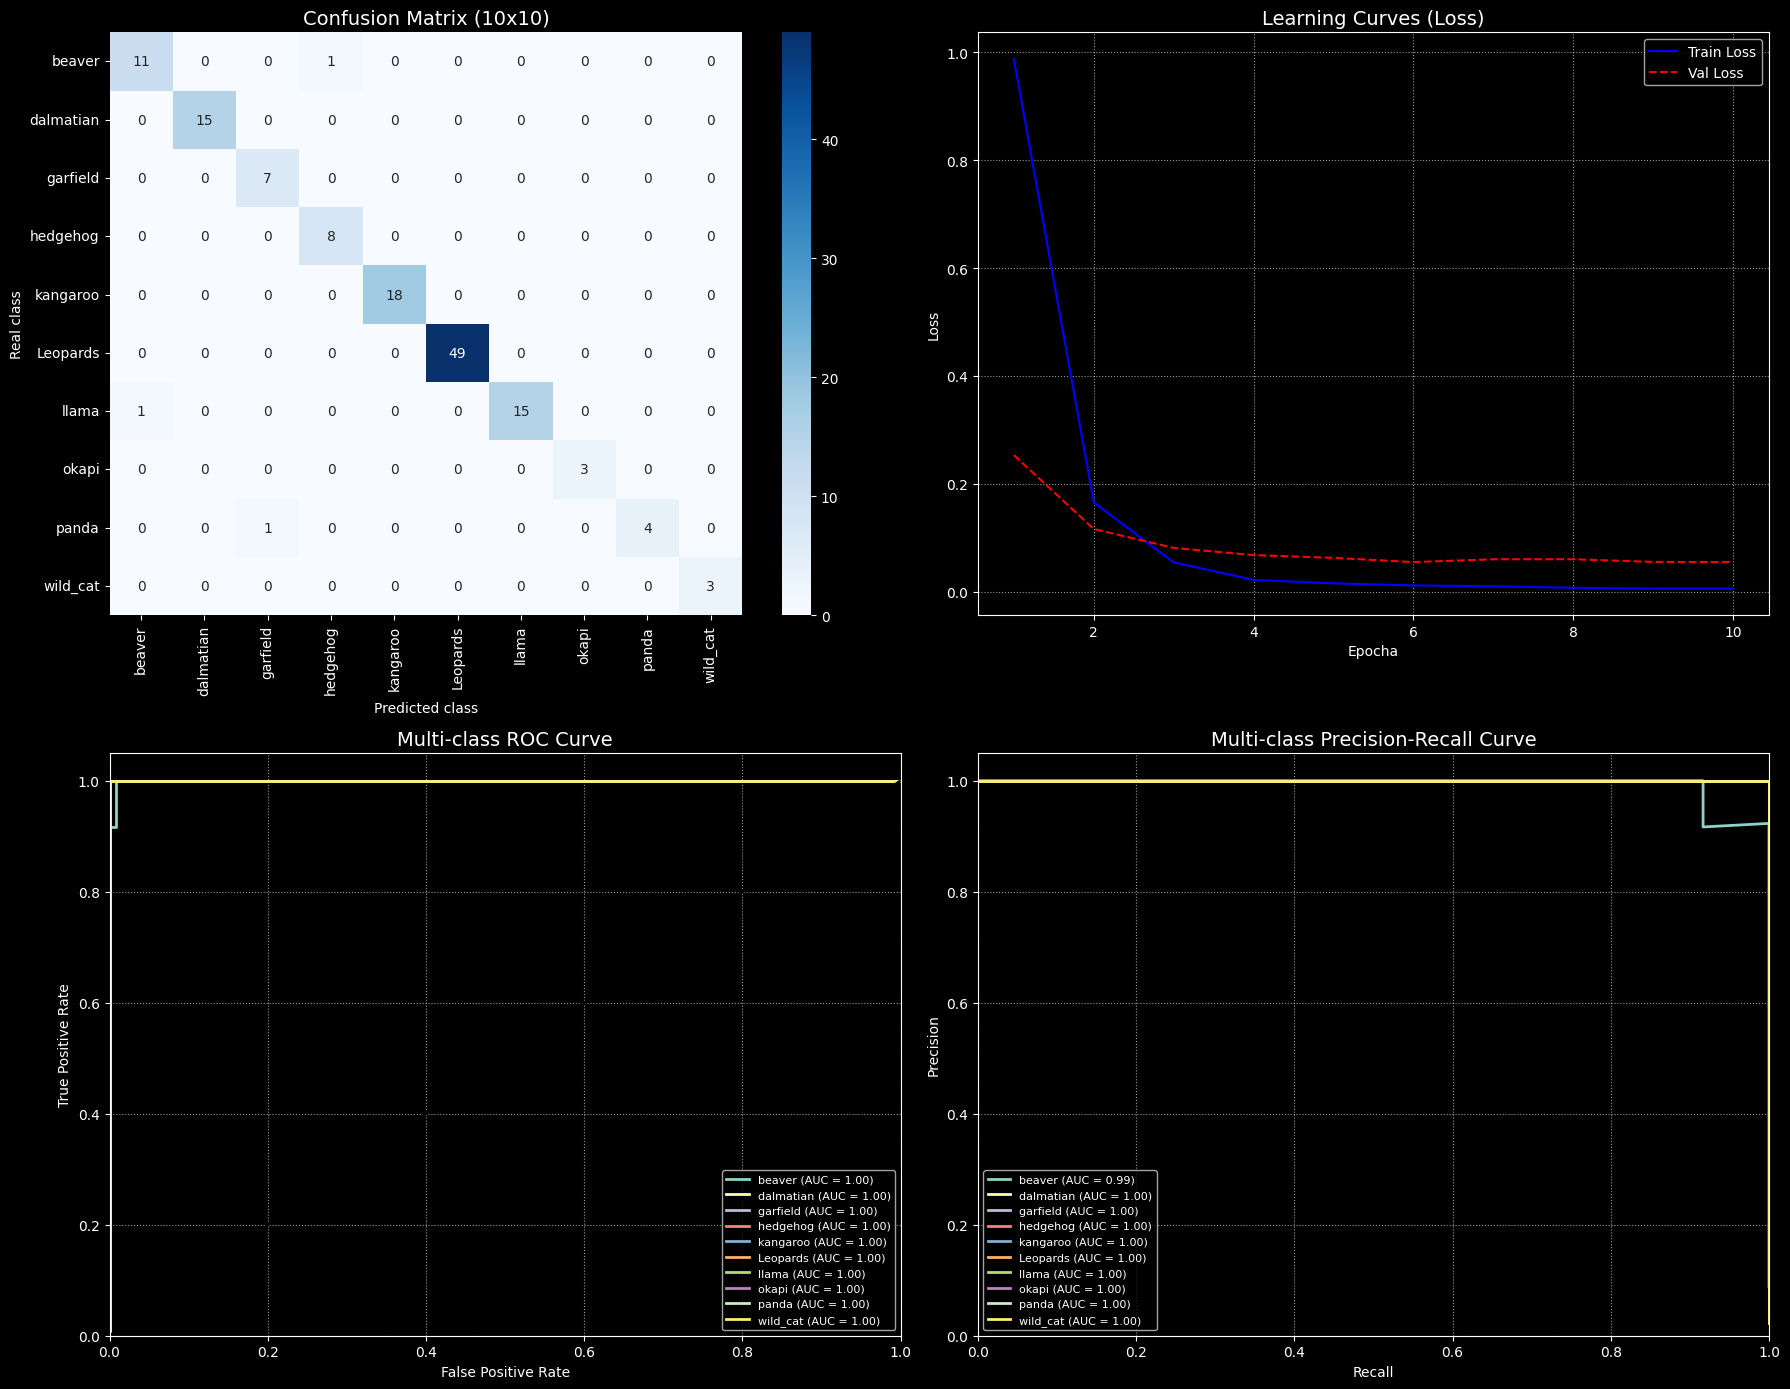

In [95]:
print("Loading best model")
finetuned_resnet.load_state_dict(torch.load('finetuned_resnet.pth'))

finetuned_resnet.eval()

best_y_true = []
best_y_pred = []
best_y_prob = []

device = torch.device("cpu")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = finetuned_resnet(inputs)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        best_y_true.extend(labels.cpu().numpy())
        best_y_pred.extend(preds.cpu().numpy())
        best_y_prob.extend(probs.cpu().numpy())

evaluate_cnn_model(
    y_true=best_y_true,
    y_pred=best_y_pred,
    y_prob=best_y_prob,
    class_names=filtered_dataset.classes,
    history=history_finetune[0]
)

Total errors in test: 3


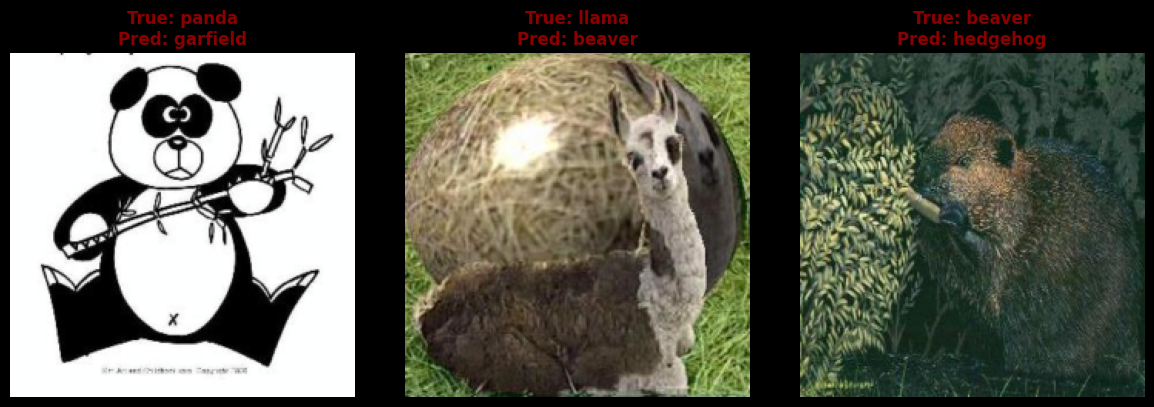

In [96]:
errors = []
for i in range(len(best_y_true)):
    if best_y_true[i] != best_y_pred[i]:
        errors.append(i)

print(f"Total errors in test: {len(errors)}")

if len(errors) > 0:
    num_to_plot = min(len(errors), 5)
    fig, axes = plt.subplots(1, num_to_plot, figsize=(4 * num_to_plot, 4))

    if num_to_plot == 1:
        axes = [axes]

    for idx, ax in zip(errors[:num_to_plot], axes):
        img_tensor, _ = test_dataset[idx]

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        img = img_tensor.permute(1, 2, 0).numpy()

        img = std * img + mean
        img = np.clip(img, 0, 1)

        true_class = filtered_dataset.classes[best_y_true[idx]]
        pred_class = filtered_dataset.classes[best_y_pred[idx]]

        ax.imshow(img)
        ax.set_title(f"True: {true_class}\nPred: {pred_class}", color='darkred', fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No errors")

In the final experiment, we unfroze the entire ResNet-18 architecture, allowing the optimizer to update all ~11 million parameters using a very low learning rate (1e-4). The model achieved a 97.79% accuracy (Top-1 Error Rate: 2.21%).

While this is an outstanding result, it is conceptually similar to the Frozen model's performance. The breakdown

1. Finetuning on small datasets
When fine-tuning a massive network on a relatively small dataset (~500 images), the model is prone to slight overfitting. Because the Frozen ResNet-18 already possessed nearly perfect feature extractors for these classes, unfreezing the weights did not drastically improve the model. Instead, it allowed the network to slightly over-adapt to the training set noise, which explains error rate (3 errors) depending on the random seed during training. We have effectively reached the theoretical limit of what this specific dataset allows without gathering more data.

2. Error analysis
The 3 images that confused the Fine-tuned model perfectly illustrate the current limitations of computer vision algorithms:

- The network consistently misclassifies a black-and-white vector clipart of a panda as garfield. Since the garfield class contains cartoonish, drawn images, the model heavily prioritizes the art style (thick black strokes, flat textures) over the actual subject.

- In one of the errors, the llama is positioned in front of a massive, spherical hay bale that occupies the majority of the frame. The network's spatial filters are overwhelmed by this dominant, unusual geometric shape in the background, causing it to misclassify the subject entirely.

- The model misclassified a beaver that is surrounded by highly textured, sharp, pine-like foliage. The convolutional filters responsible for detecting the spiky texture of a hedgehog (hedgehog class) were highly activated by the surrounding bushes, leading to a false positive based on environmental texture rather than the animal itself.

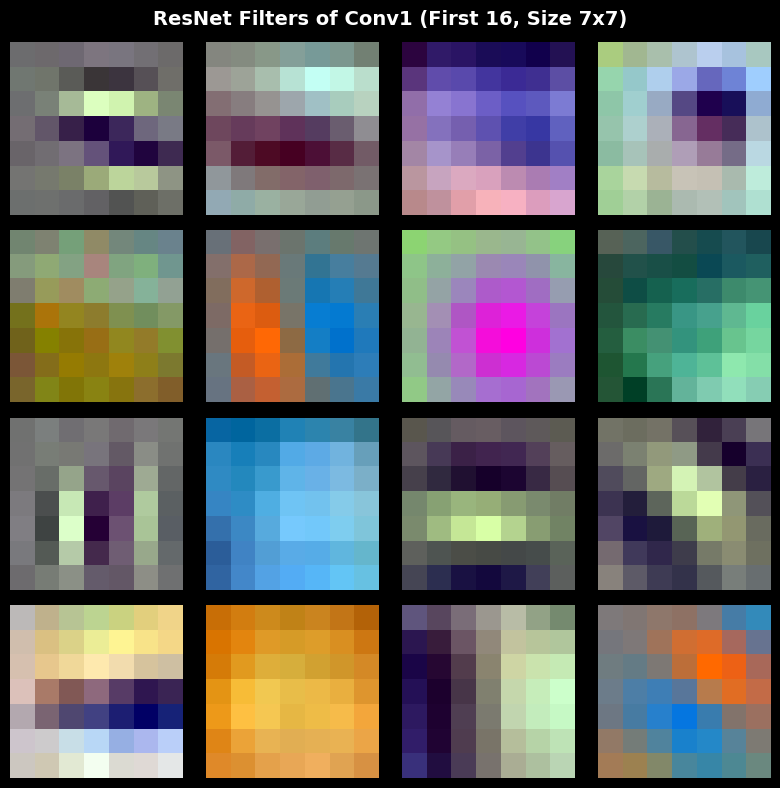

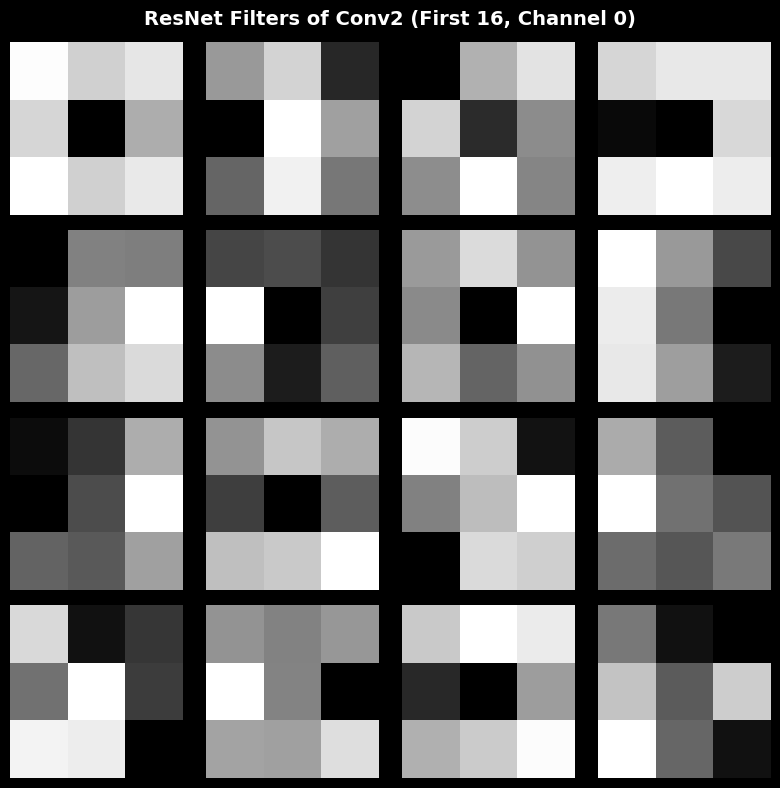

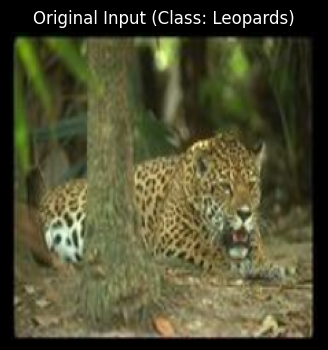

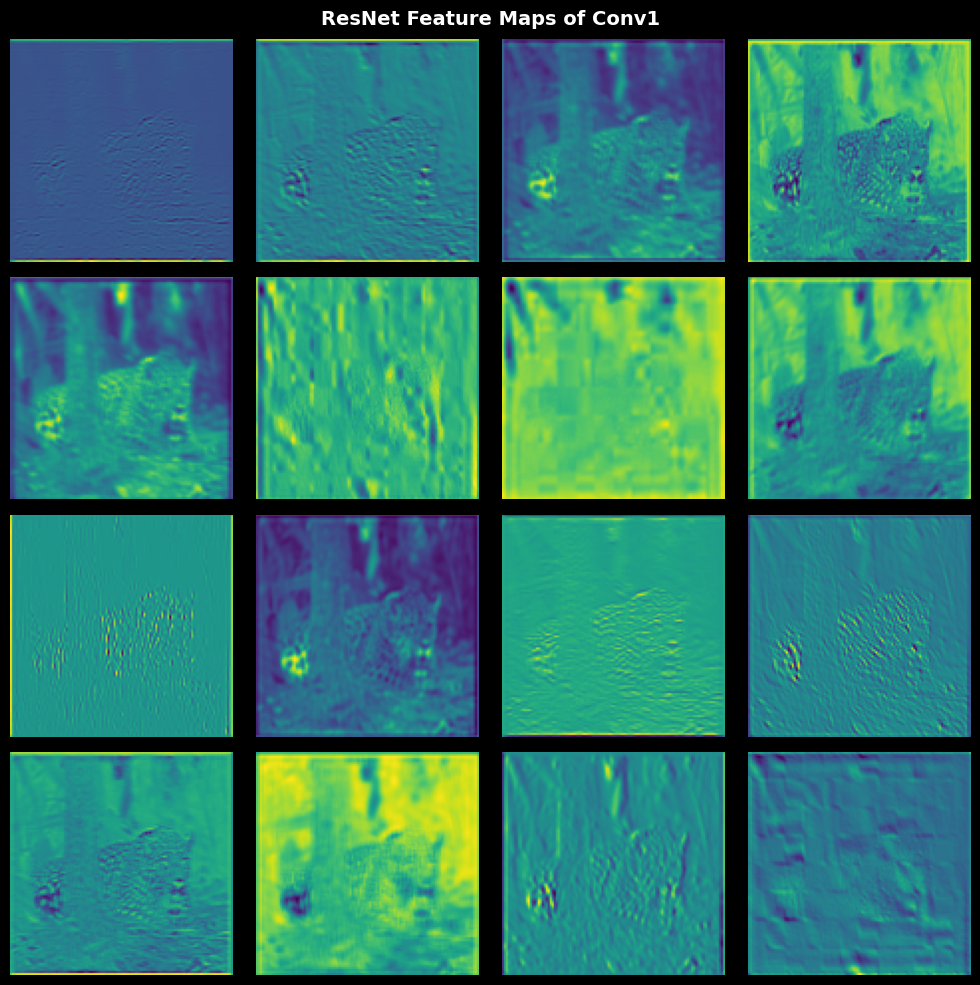

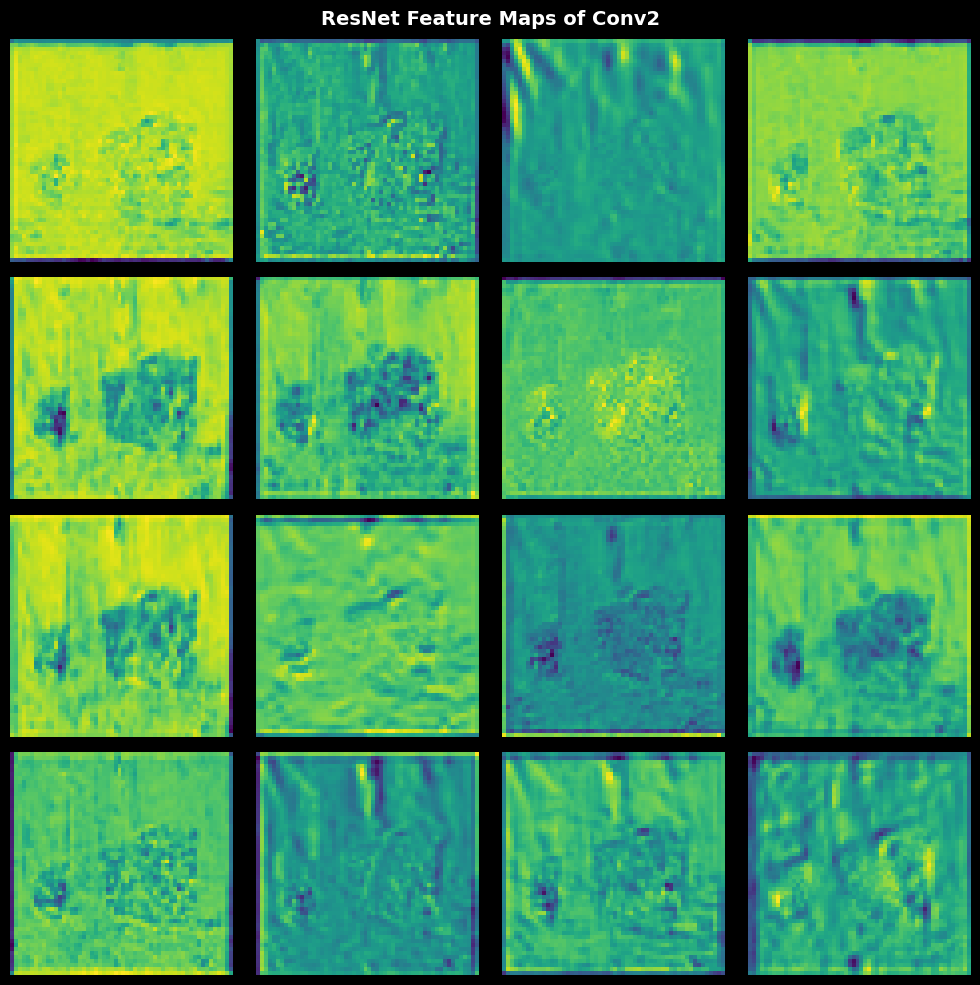

In [97]:
visualize_resnet_internals(finetuned_resnet, test_loader, filtered_dataset.classes)

### Questions

Answers are the same as for previous experiment.

The progression from a Custom Plain CNN (75% accuracy) to a transfer learning approach (~98-99% accuracy) successfully demonstrates the overwhelming power of deep, pre-trained architectures. The ResNet-18 effectively solved the vanishing gradient problem, utilized highly complex feature hierarchies (as seen in the 7x7 Conv1 filters), and proved that for small specialized datasets, utilizing pre-trained weights is far superior to training from scratch.